# Testing AirGravQC - Example Mag Data

Mark Dransfield

In [1]:
import datetime
start = datetime.datetime.now()
print(start)

2023-12-11 17:01:49.654754


## Introduction

## Import and Summarise

#### Import required modules, and set filenames for data and plan.

> First import external packages. *Some of these are probably not needed here.*

In [2]:
import importlib as im
%matplotlib widget

from pathlib import Path

> Set the paths for the `AirGravQC` software and import. (One day this will require fewer steps.)

In [3]:
# Choose `local_docs` to suit you.
# local_docs = "/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/"
local_docs = "/Users/markdransfield/"
# local_docs = "/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/"

import AirGravQC as qc

> Set the paths for the data. Usually the data would be from only one project but here we are including a variety of exemplars.

> Modify to suit your data.

In [4]:
data_root = local_docs + "Documents/GitHub/AirGravQC/examples/Airmag_GDF/"

muppetGDF_file = Path(data_root + r'Example_AeroMag_MuppetTown_2009.dat')
muppet_surv_meta = Path(data_root + r'MuppetTown_survey.json')
muppet_data_meta = Path(data_root + r'MuppetTown_data.json')
muppetHDF_file = muppetGDF_file.with_suffix('.hdf5')

In [5]:
qc.asegToHDF(muppet_surv_meta, muppet_data_meta, muppetGDF_file)

In [6]:
block_name = '30 Nov 2021 Delivery'
qc.updateProject(muppetHDF_file, acquirer='Xcalibur', blockID=block_name)
qc.updateCoordFrame(muppetHDF_file, lat='GDA94LAT', lon='GDA94LON', x='EAST_MGA', y='NORTH_MGA', time='FIDUCIAL', alt='GPS_HT')
qc.updateCoordFrame(muppetHDF_file, geoDatum='WGS84', htDatum='GRS80', projection='MGA', utmz='54')

Setting BlockID = 30 Nov 2021 Delivery for Example_AeroMag_MuppetTown_2009.hdf5.
Setting Acquirer = Xcalibur for Example_AeroMag_MuppetTown_2009.hdf5.
Changed CoordFrame attribute(s) for Example_AeroMag_MuppetTown_2009.hdf5.
Changed CoordFrame attribute(s) for Example_AeroMag_MuppetTown_2009.hdf5.


In [7]:
qc.reportWhizz(muppetHDF_file)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: 30 Nov 2021 Delivery
    ProjectName: Unknown Project

Coordinates
    AltitudeChannel: GPS_HT
    GeoDatum: WGS84
    HeightDatum: GRS80
    LatitudeChannel: GDA94LAT
    LongitudeChannel: GDA94LON
    Projection: MGA
    TimeChannel: FIDUCIAL
    UTMZone: 54
    XChannel: EAST_MGA
    YChannel: NORTH_MGA
1 lines: total distance flown [km] = 4.3

1 lines:
 ['10010']

17 channels:
 ['BGS_JOB', 'DATE', 'DEM', 'DIURNAL', 'EAST_MGA', 'FIDUCIAL', 'FLIGHT', 'GDA94LAT', 'GDA94LON', 'GPS_HT', 'IGRF', 'LINE', 'MAGCOMP', 'MAGUNCMP', 'MAG_LEV', 'NORTH_MGA', 'RAD_ALT']


In [8]:
qc.updateLineAttributes(muppetHDF_file, line_type='Xcal_can')


Setting Line attributes for Example_AeroMag_MuppetTown_2009.hdf5 according to the Xcal_can scheme.


#### Summary report of measured data

> Summary report of contents of data file. The `reportWhizz()` code can list attributes of a line via the `line=...` keyword, or a channel via the `channel=...` keyword.

In [9]:
qc.reportWhizz(muppetHDF_file, channel='MAG_LEV')

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: 30 Nov 2021 Delivery
    ProjectName: Unknown Project

Coordinates
    AltitudeChannel: GPS_HT
    GeoDatum: WGS84
    HeightDatum: GRS80
    LatitudeChannel: GDA94LAT
    LongitudeChannel: GDA94LON
    Projection: MGA
    TimeChannel: FIDUCIAL
    UTMZone: 54
    XChannel: EAST_MGA
    YChannel: NORTH_MGA
1 lines: total distance flown [km] = 4.3

1 lines:
 ['10010']

17 channels:
 ['BGS_JOB', 'DATE', 'DEM', 'DIURNAL', 'EAST_MGA', 'FIDUCIAL', 'FLIGHT', 'GDA94LAT', 'GDA94LON', 'GPS_HT', 'IGRF', 'LINE', 'MAGCOMP', 'MAGUNCMP', 'MAG_LEV', 'NORTH_MGA', 'RAD_ALT']

Channel <HDF5 dataset "MAG_LEV": shape (1050,), type "<f8">
    Alias: MAG_LEV
    Description: mag_level
    Format: f10.3
    Name: mag_lev
    Null_value: -9999.0
    Units: nT


In [10]:
qc.reportFlights(muppetHDF_file, detailed=True)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: 30 Nov 2021 Delivery
    ProjectName: Unknown Project

1 flights including 1 lines.

Flights
    1
      L10010 



In [11]:
qc.reportSampling(muppetHDF_file)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: 30 Nov 2021 Delivery
    ProjectName: Unknown Project

Sample time and distance statistics
  Min   = 1.000 s, 4.0 m
  Max   = 1.000 s, 5.0 m
  Mean  = 1.000 s, 4.1 m
  Stdev = 0 s, 0.2 m


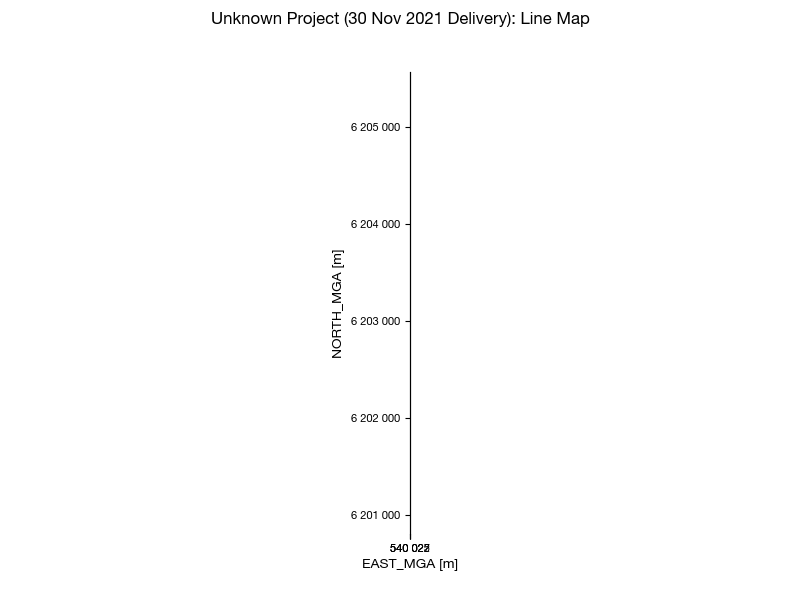

In [12]:
qc.linesMap([muppetHDF_file])

*As per contract: Correct Coordinate Frame; correct Position Datum, Projected Coordinates and Height Datum; correct units.*

Checked manually.

Coord Frame - PASS

Position Datum - WGS84 incorrect but acceptable for field data.

Projected Coordinate - UTM 54 incorrect (should be MGA 54) but acceptable for field data.

Height Datum - EGM96 geoid incorrect but acceptable for field data.

Units - all correct except gravity which is in mGal instead of µm s<sup>-2</sup>. Accept since field data.

> I accept WGS84/UTM and I accept mGal for field data even though the Deed specifies GDA2020 / MGA and um/s/s. Enforcing the contract makes extra work for the acquirer on every delivery for usually no advantage.

## Navigation and positioning
<div class="alert alert-block alert-info">
ACCEPT
<div>

#### Ground Clearance
<div class="alert alert-block alert-success">
PASS
<div>

*This is a non-contractual check that the aircraft did not approach the ground too closely; it is a simple safety check. The settings check if the aircraft came closer than 60 m from the ground. You can change this to a number of your choice.*

All ok. Also checked at 67 m just to get a plot!

In [13]:
qc.checkSafeClearance(muppetHDF_file, 40.0, clearance_chan='RAD_ALT')

Number of failed lines = 1.

Clearance too low at 31 m on line 10010.00:1


#### Ground Speed
<div class="alert alert-block alert-success">
PASS
<div>

*The contract requires the ground speed to not exceed the range +/-15% of 60 m/s for more than 1000 m.*

All the data met the specification.

Velocities not known - will calculate from positions
Nominal ground speed 60.0 m/s; allowed 54.0 : 66.0 for < 1000.0 m.

 For at least one reading in L10010.00:1, the ground speed was < 42.0 (might be unsafe).
 Checked 1 lines and 1 had some short exceedance(s).
 0 lines failed for exceedance > allowed.
 Total number of full exceedances = 0.

0 exceedances known in the database.




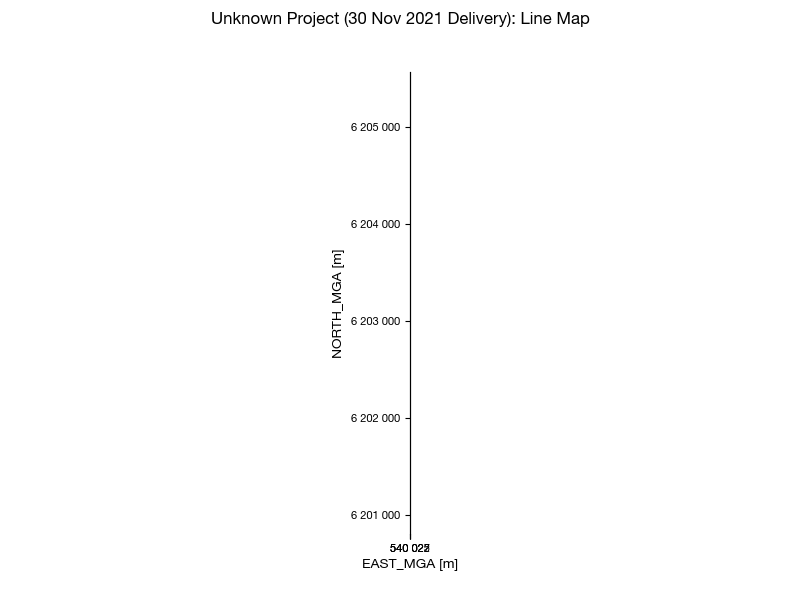

In [14]:
qc.checkSpeeds(muppetHDF_file, nominalSpeed=60., allowance=0.1, maxDistance=1000.0, plot_flag=True)

## Magnetometer
<div class="alert alert-block alert-info">
ACCEPT
<div>

In [15]:
qc.checkBasemag(muppetHDF_file, 'DIURNAL')

10010  passed easily.


In [16]:
qc.checkDiurnal(muppetHDF_file, 'DIURNAL', nSamples=1000)

In [17]:
qc.checkTCDiff4(muppetHDF_file, rawMag='MAGUNCMP')

only 983 exceedances
10010   983  <  3000  - PASS


In [18]:
# qc.eigenPlot(stumpHDF_file, lines = [], noiselimit=30.0)

## Statistics
<div class="alert alert-block alert-info">
NA
<div>

*None of the following checks are contractually required but they can give some insights to data quality.*

---
The only spikes found were at very small amplitudes on otherwise smooth fields (terrain corrections). All ok.

> The following channels should vary smoothly without spikes. You can choose different channels to test for your project but I have found this test to generally be too sensitive. The algorithm could be improved.

In [19]:
qc.checkSpikes(muppetHDF_file, fields=['BGS_JOB', 'DATE', 'DEM', 'DIURNAL', 'EAST_MGA', 'FIDUCIAL', 'FLIGHT', 
                                       'GDA94LAT', 'GDA94LON', 'GPS_HT', 'IGRF', 'LINE', 'MAGCOMP', 'MAGUNCMP', 
                                       'MAG_LEV', 'NORTH_MGA', 'RAD_ALT'])

---
The only failures are in the `Time_Day` channel and all are within 1 second of midnight. Time of day does not vary with constant slope at midnight so this is not a concern. Of course the aircraft was not flying at midnight, suggesting the the relevant clock is in the wrong time zone but this is not a concern.

> The checked fields should each vary uniformly with constant slope.

In [20]:
qc.checkConstantSlope(muppetHDF_file, fields=['BGS_JOB', 'DATE', 'DIURNAL', 'FIDUCIAL', 'FLIGHT', 'LINE'])

All fields tested were either constant or of constant slope for all lines tested.


> Just plot the mean, standard deviation and range of every channel as a for every line. A lot of information condensed here which I find useful. I just run my eye quickly over the plots looking for outliers, and I check the vertical scales to ensure that the values are in about the right range.

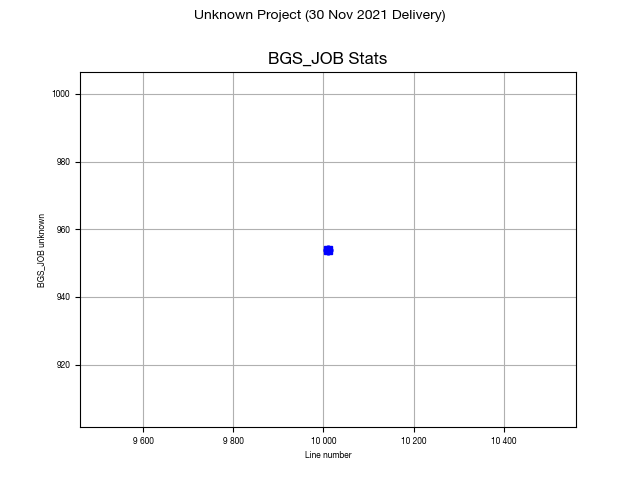

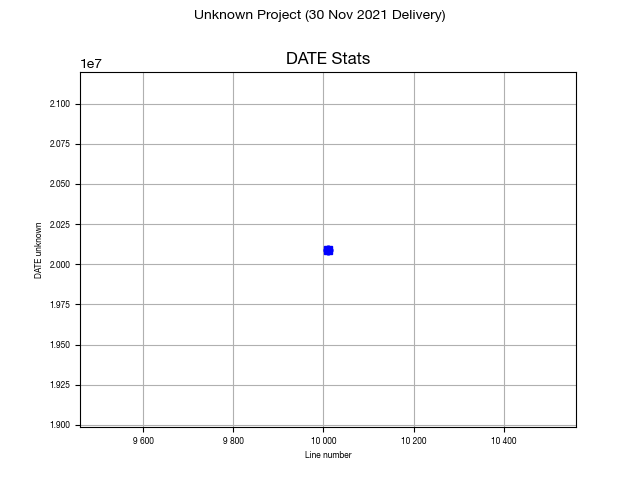

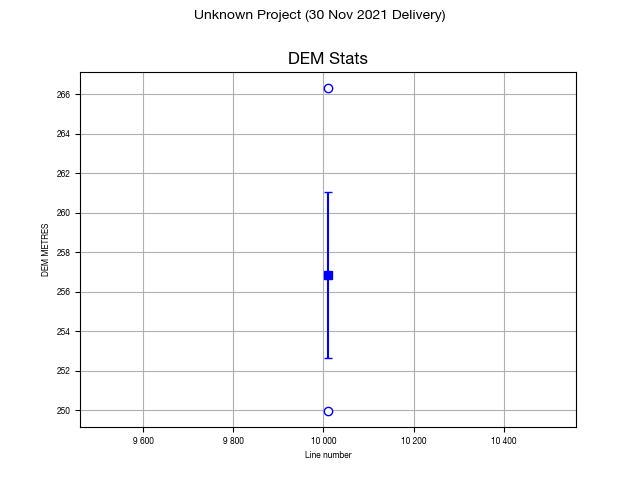

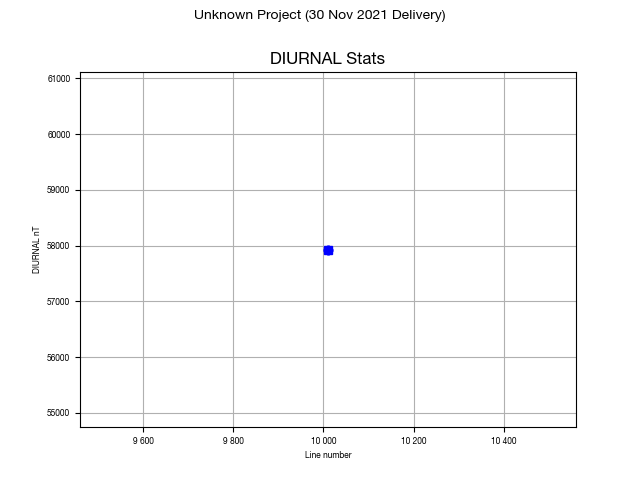

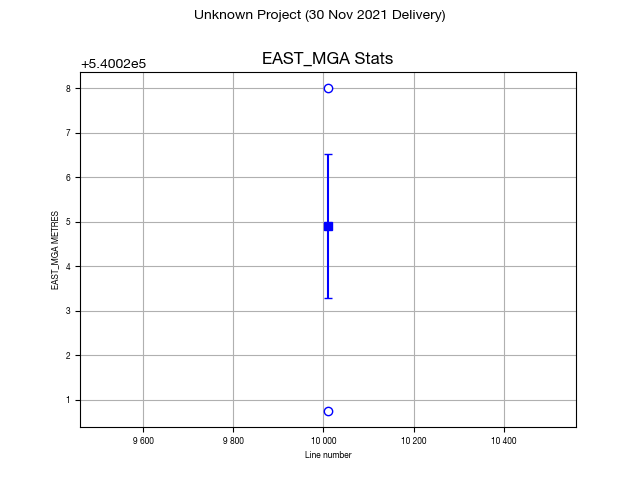

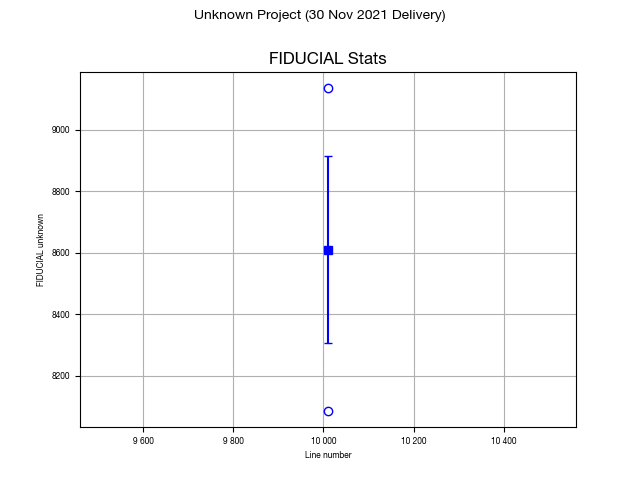

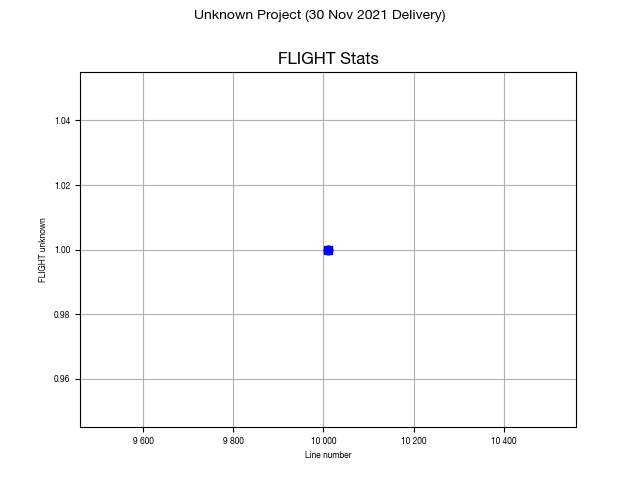

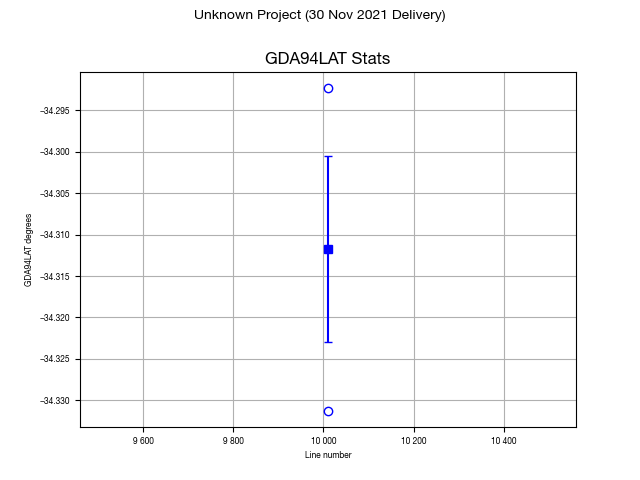

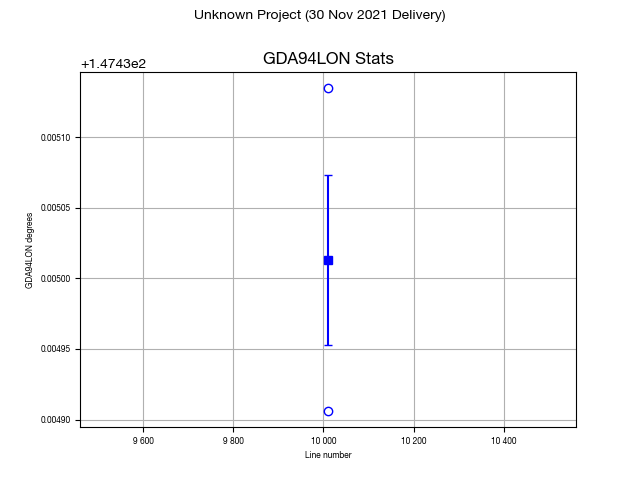

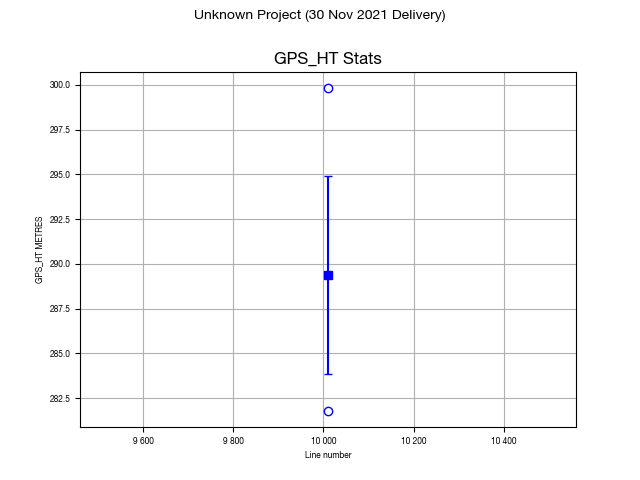

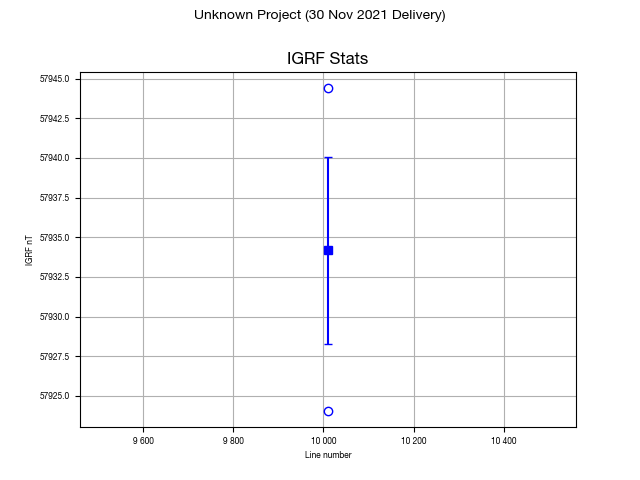

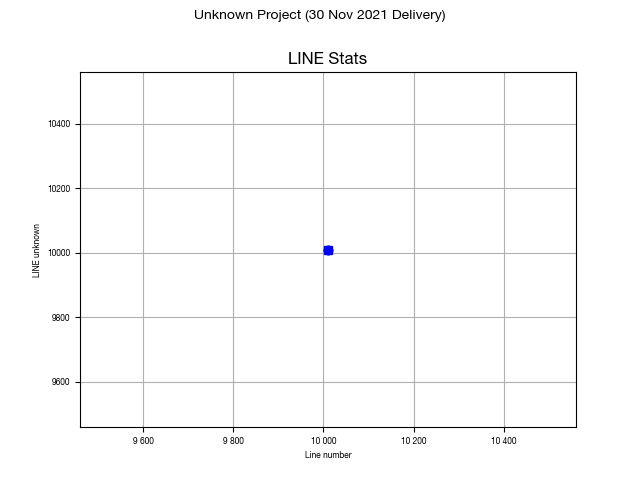

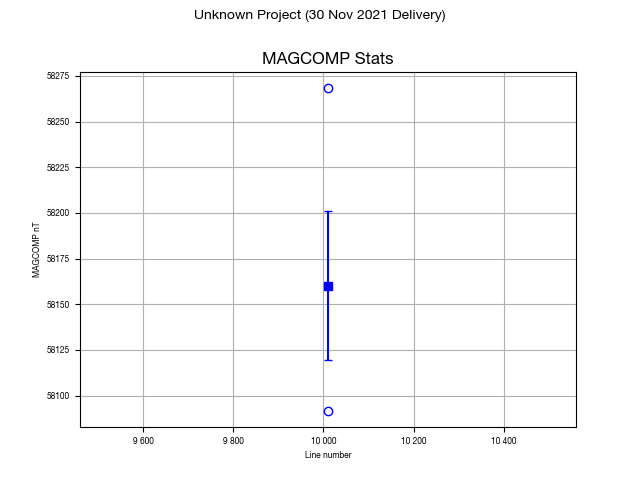

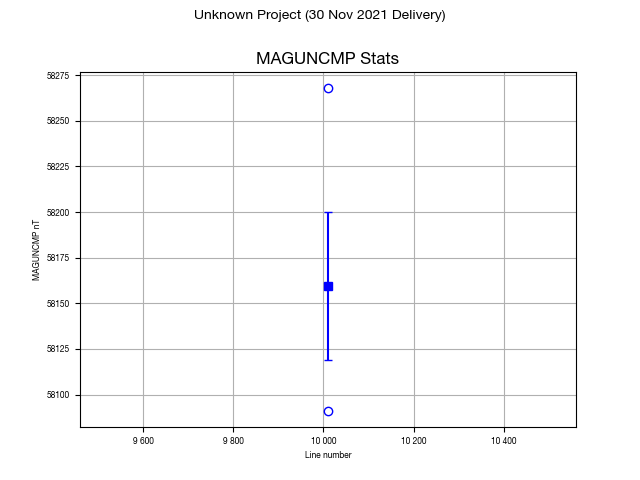

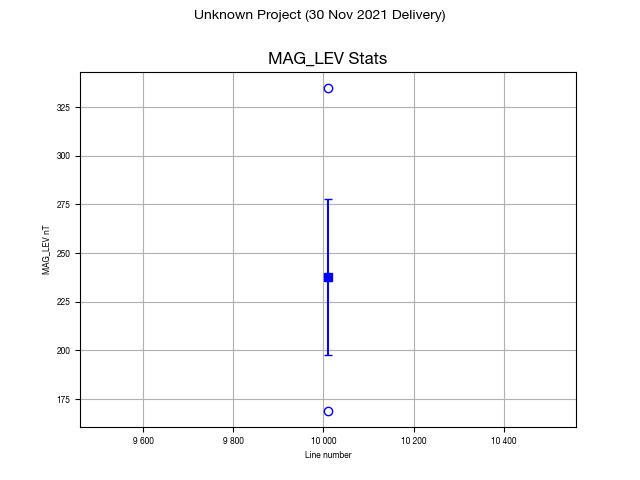

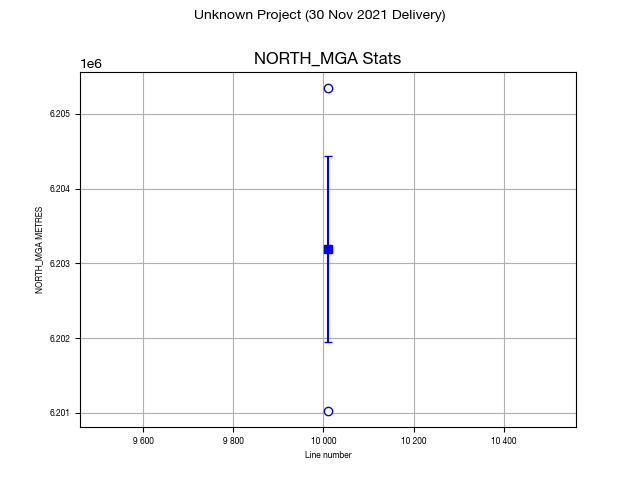

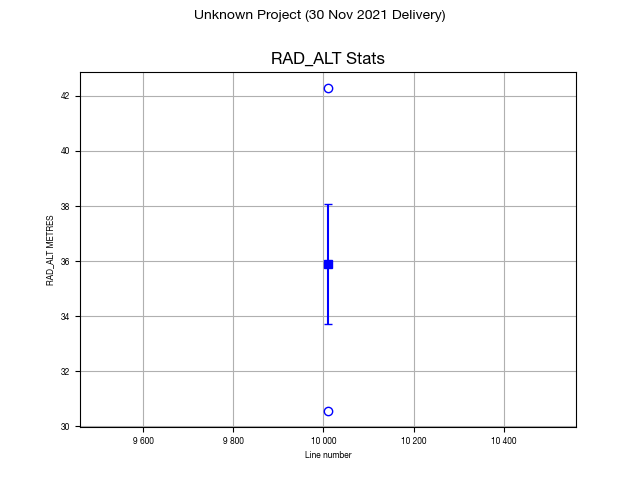

In [21]:
qc.allChanStats(muppetHDF_file, ['BGS_JOB', 'DATE', 'DEM', 'DIURNAL', 'EAST_MGA', 'FIDUCIAL', 'FLIGHT', 'GDA94LAT', 
                                 'GDA94LON', 'GPS_HT', 'IGRF', 'LINE', 'MAGCOMP', 'MAGUNCMP', 'MAG_LEV', 'NORTH_MGA', 'RAD_ALT'])

## Time taken

In [22]:
print(datetime.datetime.now() - start)

0:00:03.544719


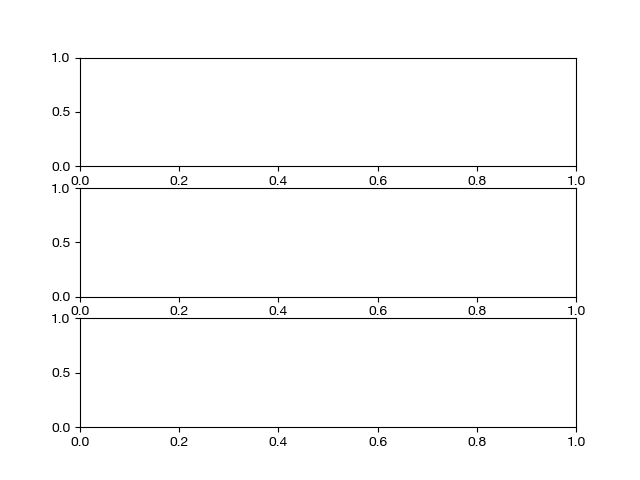

In [27]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax1 = fig.add_subplot(3,1,1)
ax2 = fig.add_subplot(3,1,2)
ax3 = fig.add_subplot(3,1,3)
